In [1]:
# Через переменные окружения (до импорта TF)
import os

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Проверка GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'✅ GPU: {gpus[0].name}')
else:
    print('⚠️ GPU не найден, используется CPU')

print(f'TensorFlow: {tf.__version__}')

2026-04-25 12:47:59.410874: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 12:47:59.463144: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-25 12:48:02.819879: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


✅ GPU: /physical_device:GPU:0
TensorFlow: 2.12.0


In [3]:
print(dir(tf.keras.applications))

['ConvNeXtBase', 'ConvNeXtLarge', 'ConvNeXtSmall', 'ConvNeXtTiny', 'ConvNeXtXLarge', 'DenseNet121', 'DenseNet169', 'DenseNet201', 'EfficientNetB0', 'EfficientNetB1', 'EfficientNetB2', 'EfficientNetB3', 'EfficientNetB4', 'EfficientNetB5', 'EfficientNetB6', 'EfficientNetB7', 'EfficientNetV2B0', 'EfficientNetV2B1', 'EfficientNetV2B2', 'EfficientNetV2B3', 'EfficientNetV2L', 'EfficientNetV2M', 'EfficientNetV2S', 'InceptionResNetV2', 'InceptionV3', 'MobileNet', 'MobileNetV2', 'MobileNetV3Large', 'MobileNetV3Small', 'NASNetLarge', 'NASNetMobile', 'RegNetX002', 'RegNetX004', 'RegNetX006', 'RegNetX008', 'RegNetX016', 'RegNetX032', 'RegNetX040', 'RegNetX064', 'RegNetX080', 'RegNetX120', 'RegNetX160', 'RegNetX320', 'RegNetY002', 'RegNetY004', 'RegNetY006', 'RegNetY008', 'RegNetY016', 'RegNetY032', 'RegNetY040', 'RegNetY064', 'RegNetY080', 'RegNetY120', 'RegNetY160', 'RegNetY320', 'ResNet101', 'ResNet101V2', 'ResNet152', 'ResNet152V2', 'ResNet50', 'ResNet50V2', 'ResNetRS101', 'ResNetRS152', 'ResNe

In [4]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# Параметры
DATASET_PATH = '/home/jupyter/project/tiny'  
IMG_SIZE = (224, 224)      # ResNet входной размер
BATCH_SIZE = 8
EPOCHS = 30
VALIDATION_SPLIT = 0.2
SEED = 42

In [6]:
# Загрузка тренировочных данных
train_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Загрузка валидационных данных
val_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Информация о датасете
CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f'Классы ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Батчей в train: {len(train_ds)}')
print(f'Батчей в val:   {len(val_ds)}')

Found 14027 files belonging to 28 classes.
Using 11222 files for training.


2026-04-25 12:48:09.958970: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13944 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:81:00.0, compute capability: 7.5


Found 14027 files belonging to 28 classes.
Using 2805 files for validation.
Классы (28): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing', 'space']
Батчей в train: 1403
Батчей в val:   351


2026-04-25 12:48:10.689395: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [11222]
	 [[{{node Placeholder/_0}}]]
2026-04-25 12:48:10.689854: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [11222]
	 [[{{node Placeholder/_4}}]]


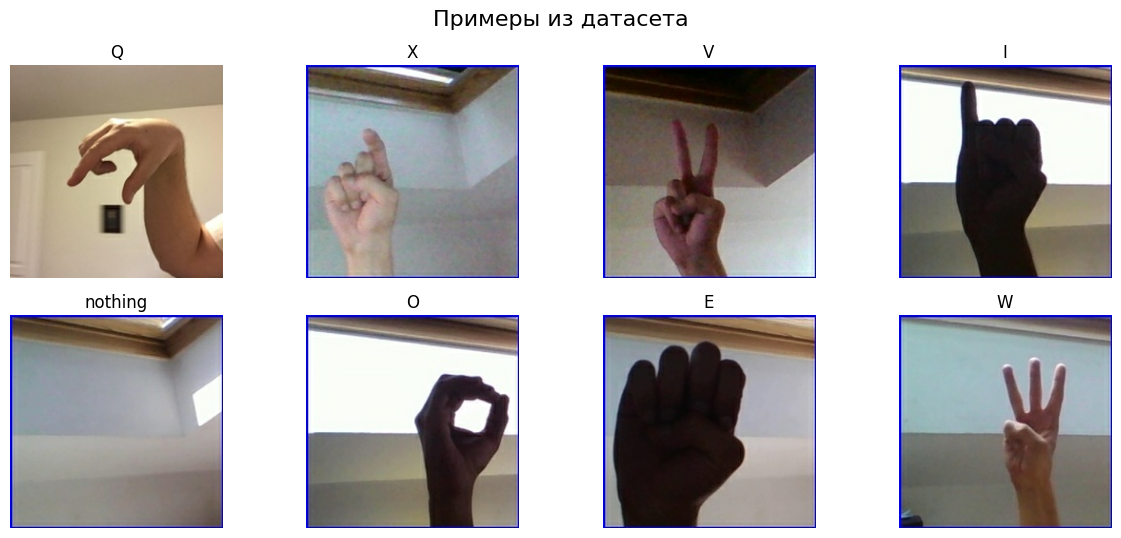

In [7]:

plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(min(12, BATCH_SIZE)):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        label_idx = np.argmax(labels[i])
        plt.title(CLASS_NAMES[label_idx], fontsize=12)
        plt.axis('off')
plt.suptitle('Примеры из датасета', fontsize=16)
plt.tight_layout()
plt.show()


In [8]:

AUTOTUNE = tf.data.AUTOTUNE

# Аугментация данных
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
])

def prepare(ds, augment=False):
    # Нормализация для ResNet
    ds = ds.map(
        lambda x, y: (tf.keras.applications.resnet50.preprocess_input(x), y),
        num_parallel_calls=AUTOTUNE
    )
    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )
    return ds.cache().prefetch(buffer_size=AUTOTUNE)

train_ds = prepare(train_ds, augment=False).cache()
val_ds = prepare(val_ds, augment=False).cache()

print('✅ Данные подготовлены')


✅ Данные подготовлены


In [9]:
def build_model(num_classes):
    # Базовая модель ResNet50V2 
    base_model = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )
    
    # Заморозить базовую модель
    base_model.trainable = False
    
    # Построить модель
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(NUM_CLASSES)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50v2 (Functional)     (None, 7, 7, 2048)        23564800  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 2048)             8192      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 dropout (Dropout)           (None, 512)               0     

In [10]:
# Колбэки
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

# Компиляция
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('🚀 Фаза 1: Обучение верхних слоёв...')
history1 = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

🚀 Фаза 1: Обучение верхних слоёв...


2026-04-25 12:48:15.481190: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [11222]
	 [[{{node Placeholder/_4}}]]
2026-04-25 12:48:15.481660: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [11222]
	 [[{{node Placeholder/_4}}]]


Epoch 1/30


2026-04-25 12:48:18.807396: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8900
2026-04-25 12:48:18.924278: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-25 12:48:19.876263: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x55b4bcf57bd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-25 12:48:19.876309: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-04-25 12:48:19.881419: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-25 12:48:19.961392: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-25 12:48:20.020073: I ./tensorflow/compiler/jit/device_compiler.h:180] Com

1403/1403 [==============================] - ETA: 0s - loss: 3.0323 - accuracy: 0.1567

2026-04-25 12:48:59.911300: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [2805]
	 [[{{node Placeholder/_0}}]]
2026-04-25 12:48:59.911791: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [2805]
	 [[{{node Placeholder/_0}}]]



Epoch 1: val_accuracy improved from -inf to 0.31230, saving model to best_model.keras
1403/1403 [==============================] - 58s 37ms/step - loss: 3.0323 - accuracy: 0.1567 - val_loss: 2.2672 - val_accuracy: 0.3123 - lr: 0.0010
Epoch 2/30
1403/1403 [==============================] - ETA: 0s - loss: 2.4059 - accuracy: 0.2747
Epoch 2: val_accuracy improved from 0.31230 to 0.37825, saving model to best_model.keras
1403/1403 [==============================] - 51s 36ms/step - loss: 2.4059 - accuracy: 0.2747 - val_loss: 1.9781 - val_accuracy: 0.3783 - lr: 0.0010
Epoch 3/30
1401/1403 [============================>.] - ETA: 0s - loss: 2.1424 - accuracy: 0.3364
Epoch 3: val_accuracy improved from 0.37825 to 0.43494, saving model to best_model.keras
1403/1403 [==============================] - 49s 35ms/step - loss: 2.1421 - accuracy: 0.3363 - val_loss: 1.7891 - val_accuracy: 0.4349 - lr: 0.0010
Epoch 4/30
1401/1403 [============================>.] - ETA: 0s - loss: 1.9351 - accuracy: 0.39

In [11]:
model.save_weights('/home/jupyter/project/resNet/weights.h5')
val_loss_before, val_acc_before = model.evaluate(val_ds, verbose=0)
print(f"📊 Точность после фазы 1: {val_acc_before:.4f}")

📊 Точность после фазы 1: 0.6902


In [12]:
 # Разморозить последние слои ResNet
base_model.trainable = True

# КРИТИЧНО: BatchNorm слои должны оставаться замороженными!
for layer in base_model.layers:
    # Заморозить BN слои — они разрушают обученную статистику
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Заморозить первые N слоёв
FREEZE_UNTIL = 40  # можно настроить
for layer in base_model.layers[:FREEZE_UNTIL]:
    layer.trainable = False

# Статистика
total_layers = len(base_model.layers)
trainable_bn = sum(1 for l in base_model.layers 
                   if isinstance(l, tf.keras.layers.BatchNormalization) 
                   and l.trainable)
print(f"Всего слоёв: {total_layers}")
print(f"Заморожено: {FREEZE_UNTIL}")
print(f"Обучаемых BN (должно быть 0): {trainable_bn}")
print(f"Обучаемых слоёв модели: {sum(1 for l in model.layers if l.trainable)}")

Всего слоёв: 190
Заморожено: 40
Обучаемых BN (должно быть 0): 0
Обучаемых слоёв модели: 9


In [13]:
callbacks2 = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        verbose=1
    )
]
# Перекомпилировать с меньшим LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('🚀 Фаза 2: Fine-tuning...')
history2 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks2
)

🚀 Фаза 2: Fine-tuning...
Epoch 1/20
1403/1403 [==============================] - ETA: 0s - loss: 0.7422 - accuracy: 0.7610
Epoch 1: val_accuracy improved from -inf to 0.66061, saving model to best_model.keras
1403/1403 [==============================] - 128s 81ms/step - loss: 0.7422 - accuracy: 0.7610 - val_loss: 1.6169 - val_accuracy: 0.6606 - lr: 1.0000e-06
Epoch 2/20
1403/1403 [==============================] - ETA: 0s - loss: 0.8213 - accuracy: 0.7428
Epoch 2: val_accuracy did not improve from 0.66061
1403/1403 [==============================] - 108s 77ms/step - loss: 0.8213 - accuracy: 0.7428 - val_loss: 1.7081 - val_accuracy: 0.6442 - lr: 1.0000e-06
Epoch 3/20
1403/1403 [==============================] - ETA: 0s - loss: 0.8110 - accuracy: 0.7449
Epoch 3: val_accuracy did not improve from 0.66061
1403/1403 [==============================] - 109s 77ms/step - loss: 0.8110 - accuracy: 0.7449 - val_loss: 1.7806 - val_accuracy: 0.6381 - lr: 1.0000e-06
Epoch 4/20
1403/1403 [============

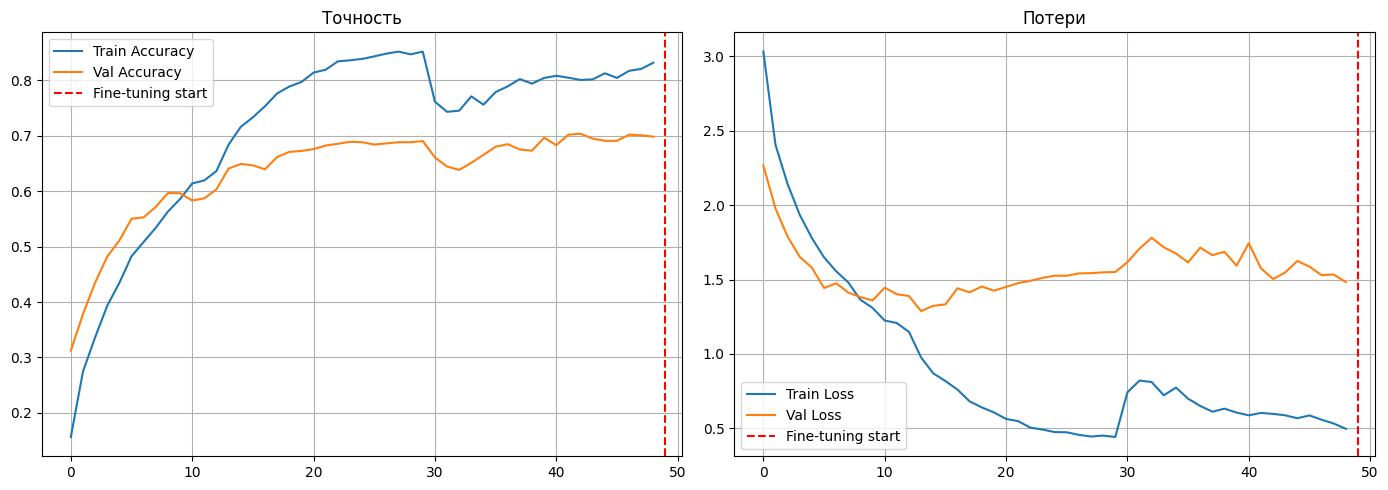

In [14]:
def plot_history(history1, history2=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Объединить историю
    acc = history1.history['accuracy']
    val_acc = history1.history['val_accuracy']
    loss = history1.history['loss']
    val_loss = history1.history['val_loss']
    
    if history2:
        acc += history2.history['accuracy']
        val_acc += history2.history['val_accuracy']
        loss += history2.history['loss']
        val_loss += history2.history['val_loss']
    
    epochs_range = range(len(acc))
    
    # График точности
    ax1.plot(epochs_range, acc, label='Train Accuracy')
    ax1.plot(epochs_range, val_acc, label='Val Accuracy')
    ax1.axvline(x=len(history1.history['accuracy']),
                color='red', linestyle='--', label='Fine-tuning start')
    ax1.set_title('Точность')
    ax1.legend()
    ax1.grid(True)
    
    # График потерь
    ax2.plot(epochs_range, loss, label='Train Loss')
    ax2.plot(epochs_range, val_loss, label='Val Loss')
    ax2.axvline(x=len(history1.history['loss']),
                color='red', linestyle='--', label='Fine-tuning start')
    ax2.set_title('Потери')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history(history1, history2)

              precision    recall  f1-score   support

           A       0.54      0.64      0.58        89
           B       0.70      0.64      0.67       111
           C       0.70      0.71      0.71        94
           D       0.73      0.64      0.68       101
           E       0.73      0.63      0.67        91
           F       0.66      0.73      0.69        96
           G       0.76      0.74      0.75       102
           H       0.64      0.85      0.73        92
           I       0.78      0.63      0.70       104
           J       0.79      0.84      0.81        92
           K       0.78      0.73      0.76       101
           L       0.77      0.76      0.77        99
           M       0.64      0.73      0.68        96
           N       0.78      0.72      0.75       111
           O       0.73      0.54      0.62       115
           P       0.87      0.82      0.85       101
           Q       0.84      0.76      0.80        92
           R       0.61    

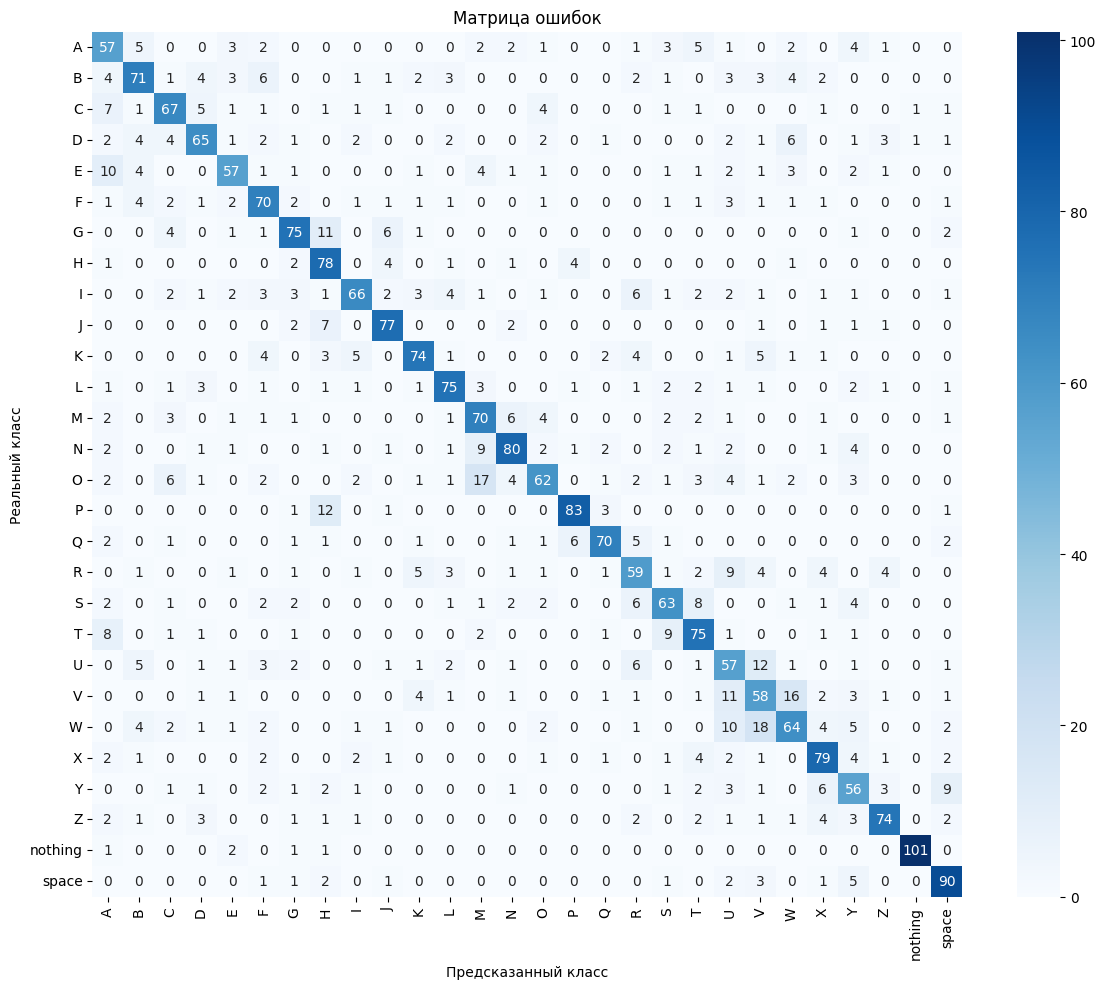

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Предсказания
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

# Отчёт
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap='Blues')
plt.title('Матрица ошибок')
plt.ylabel('Реальный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

In [16]:
def predict_image(image_path, model, class_names):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    img_array = tf.keras.applications.resnet50.preprocess_input(img_array)
    
    predictions= model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100
    
    plt.figure(figsize=(6, 6))
    plt.imshow(tf.keras.utils.load_img(image_path))
    plt.title(f'Жест: {predicted_class}\nУверенность: {confidence:.1f}%',
              fontsize=14)
    plt.axis('off')
    plt.show()
    
    return predicted_class, confidence


predict_image('/work/datasets/asl_alphabet_test/T_test.jpg', model, CLASS_NAMES)

FileNotFoundError: [Errno 2] No such file or directory: '/work/datasets/asl_alphabet_test/T_test.jpg'

In [17]:
# Сохранить модель
model.save('/home/jupyter/project/resNet/sign_language_resnet.keras')
print('✅ Модель сохранена!')

# Загрузить модель
# model = tf.keras.models.load_model('sign_language_resnet.keras')

✅ Модель сохранена!
